In [40]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
import pyodbc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from scipy import stats

# Configuration de l'URI de suivi MLflow
mlflow.set_tracking_uri("http://localhost:5000")

# Fonction pour charger les données


In [41]:
def load_data():
    load_dotenv()
    server = os.getenv('DB_SERVER')
    database = os.getenv('DB_DATABASE')
    username = os.getenv('DB_USERNAME')
    password = os.getenv('DB_PASSWORD')
    driver = '{ODBC Driver 17 for SQL Server}'
    
    cnxn = pyodbc.connect('DRIVER='+driver+';SERVER='+server+';PORT=1433;DATABASE='+database+';UID='+username+';PWD='+ password)
    
    df_produit = pd.read_sql_query('SELECT * FROM Produit', cnxn)
    df_caracteristiques = pd.read_sql_query('SELECT * FROM Caracteristiques', cnxn)
    df_dimensions = pd.read_sql_query('SELECT * FROM Dimensions', cnxn)
    
    cnxn.close()
    
    df = pd.merge(df_produit, df_caracteristiques, on='ID_Produit')
    df = pd.merge(df, df_dimensions, on='ID_Produit')
    
    return df

# Fonction pour préparer les données


In [42]:
def prepare_data(df):
    X = df.drop(columns=['Prix','URL_Produit','Info_generale','Date_scrap','ID_Caracteristique','ID_Dimension','ID_Produit'])
    y = df['Prix']
    
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = X[col].astype('category').cat.codes
    
    return X, y

# Charger les données
df = load_data()
X, y = prepare_data(df)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


C:\Users\impej\AppData\Local\Temp\ipykernel_22288\3083428070.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_produit = pd.read_sql_query('SELECT * FROM Produit', cnxn)
C:\Users\impej\AppData\Local\Temp\ipykernel_22288\3083428070.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_caracteristiques = pd.read_sql_query('SELECT * FROM Caracteristiques', cnxn)
C:\Users\impej\AppData\Local\Temp\ipykernel_22288\3083428070.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dimensions = pd.read_sql_query('SELECT * F

# Récupérer les informations du modèle le plus récent


In [43]:
latest_run = mlflow.search_runs(order_by=["start_time desc"]).iloc[0]
model = mlflow.sklearn.load_model(f"runs:/{latest_run.run_id}/model")

# Récupérer les métriques directement depuis MLflow
r2_train = latest_run["metrics.r2_train"]
r2_test = latest_run["metrics.r2_test"]
mse_train = latest_run["metrics.mse_train"]
mse_test = latest_run["metrics.mse_test"]
mae_train = latest_run["metrics.mae_train"]
mae_test = latest_run["metrics.mae_test"]

# Créer un DataFrame pour les scores
scores_df = pd.DataFrame({
    "Score": ["R2 (entraînement)", "R2 (test)", "MSE (entraînement)", "MSE (test)", "MAE (entraînement)", "MAE (test)"],
    "Valeur": [r2_train, r2_test, mse_train, mse_test, mae_train, mae_test]
})

# Afficher les scores
print("Scores du modèle le plus récent :")
print(scores_df)

Scores du modèle le plus récent :
                Score     Valeur
0   R2 (entraînement)   0.991941
1           R2 (test)   0.978480
2  MSE (entraînement)  14.874386
3          MSE (test)  40.022540
4  MAE (entraînement)   2.117510
5          MAE (test)   3.433708


# Visualisation des métriques


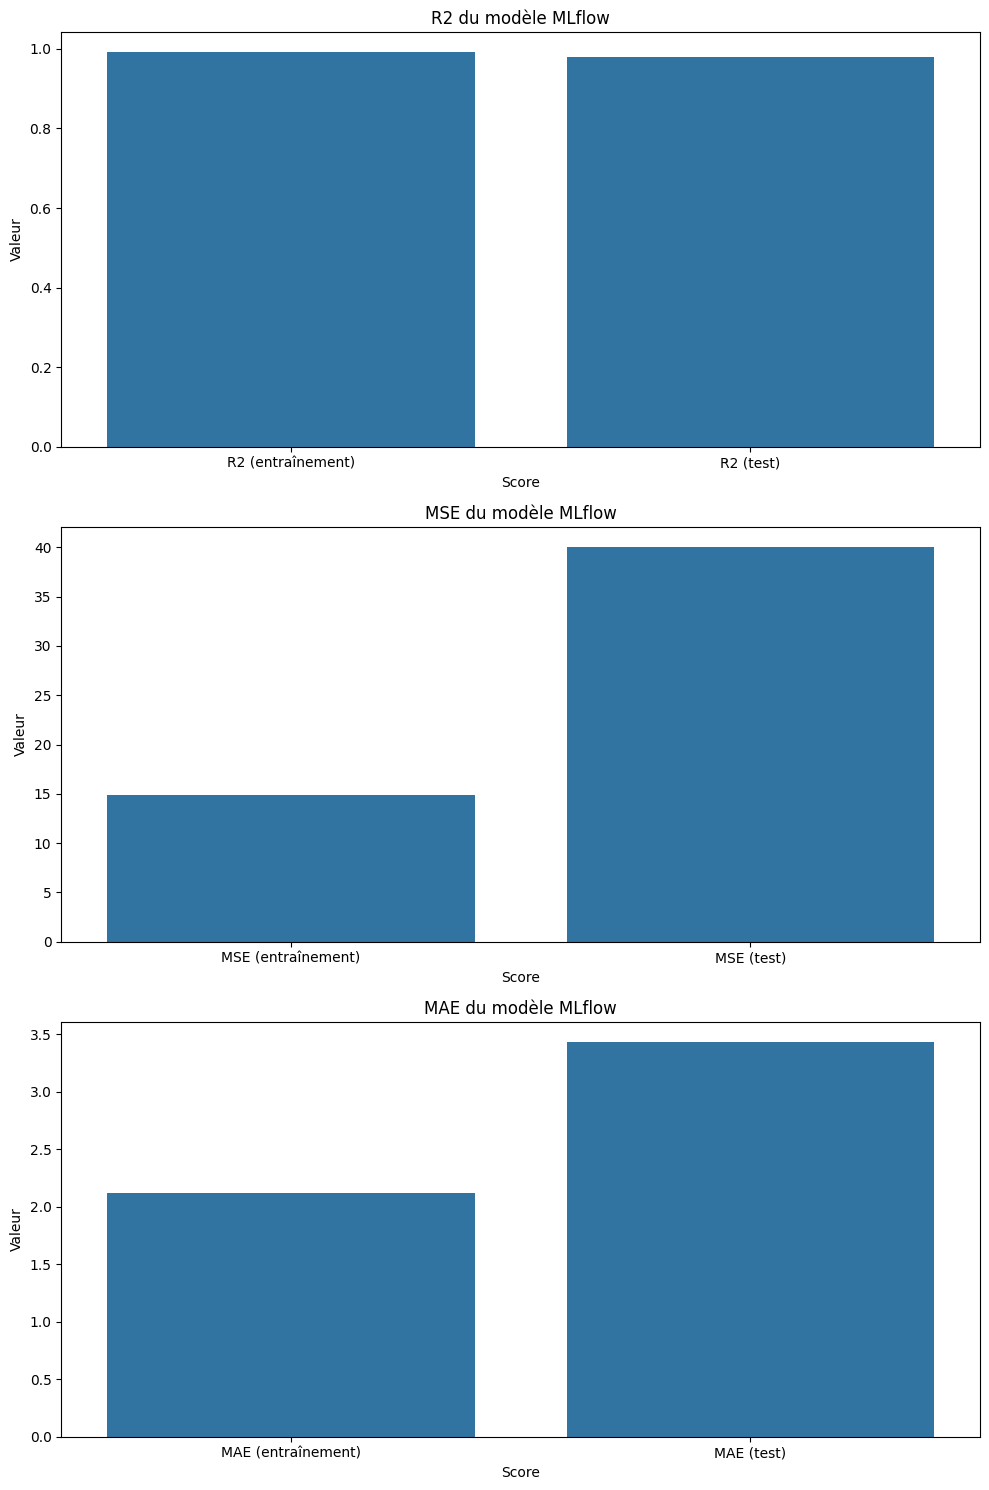


Détection de drift


In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

sns.barplot(x="Score", y="Valeur", data=scores_df[scores_df["Score"].str.contains("R2")], ax=ax1)
ax1.set_title("R2 du modèle MLflow")
ax1.set_xlabel("Score")
ax1.set_ylabel("Valeur")

sns.barplot(x="Score", y="Valeur", data=scores_df[scores_df["Score"].str.contains("MSE")], ax=ax2)
ax2.set_title("MSE du modèle MLflow")
ax2.set_xlabel("Score")
ax2.set_ylabel("Valeur")

sns.barplot(x="Score", y="Valeur", data=scores_df[scores_df["Score"].str.contains("MAE")], ax=ax3)
ax3.set_title("MAE du modèle MLflow")
ax3.set_xlabel("Score")
ax3.set_ylabel("Valeur")

plt.tight_layout()
plt.show()

# Détection de drift
print("\nDétection de drift")

In [45]:
# Afficher les noms de toutes les colonnes avec leur index


In [46]:
print("Liste des colonnes disponibles :")
for i, col in enumerate(X.columns):
    print(f"{i}: {col}")





Liste des colonnes disponibles :
0: Descriptif
1: Note
2: Marque
3: Consommation
4: Indice_Pluie
5: Bruit
6: Saisonalite
7: Type_Vehicule
8: Runflat
9: Largeur
10: Hauteur
11: Diametre
12: Charge
13: Vitesse


# Sélection de la variable pour la détection de drift


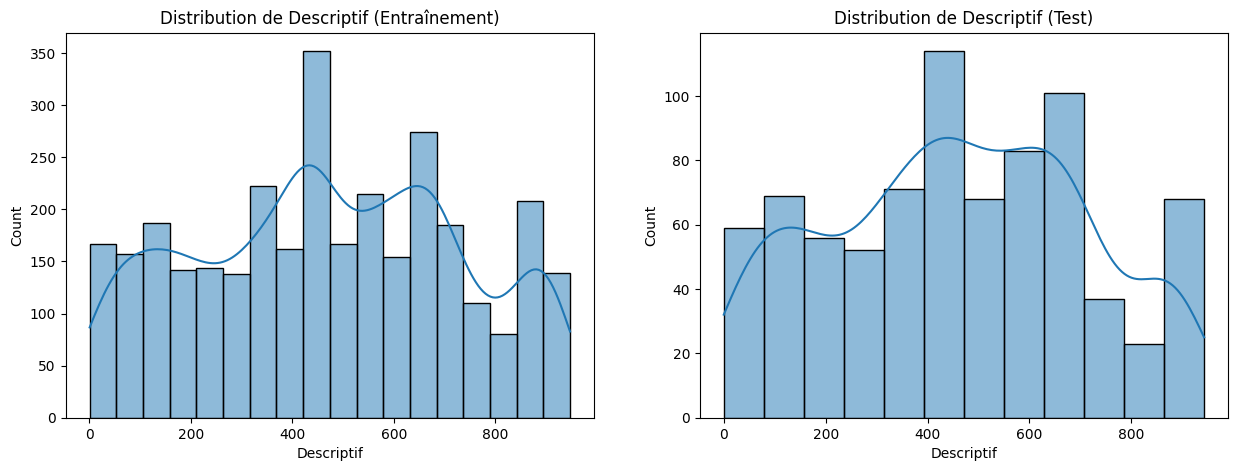

Test de Kolmogorov-Smirnov pour Descriptif:
Statistique KS: 0.0335
p-value: 0.4586
Pas de drift significatif détecté pour Descriptif


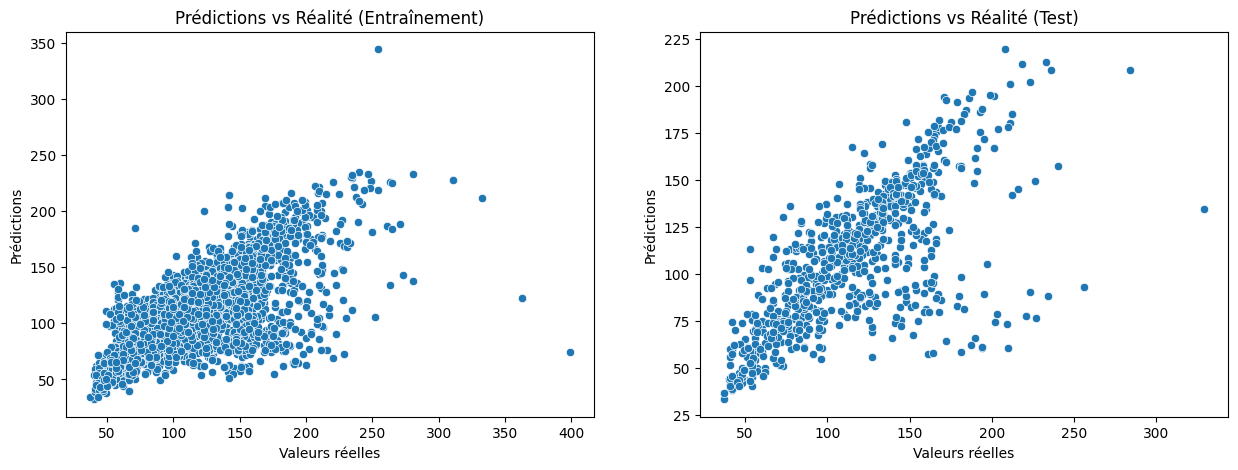

In [47]:
selected_feature = X.columns[0]  # Vous pouvez changer ceci pour tester différentes caractéristiques

# Visualisation de la distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(X_train[selected_feature], kde=True, ax=ax1)
ax1.set_title(f"Distribution de {selected_feature} (Entraînement)")

sns.histplot(X_test[selected_feature], kde=True, ax=ax2)
ax2.set_title(f"Distribution de {selected_feature} (Test)")

plt.show()

# Test statistique pour le drift
ks_statistic, p_value = stats.ks_2samp(X_train[selected_feature], X_test[selected_feature])

print(f"Test de Kolmogorov-Smirnov pour {selected_feature}:")
print(f"Statistique KS: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.07:
    print(f"Attention : Drift potentiel détecté pour {selected_feature} (p-value < 0.07)")
else:
    print(f"Pas de drift significatif détecté pour {selected_feature}")

# Comparaison des prédictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=y_train, y=y_pred_train, ax=ax1)
ax1.set_title("Prédictions vs Réalité (Entraînement)")
ax1.set_xlabel("Valeurs réelles")
ax1.set_ylabel("Prédictions")

sns.scatterplot(x=y_test, y=y_pred_test, ax=ax2)
ax2.set_title("Prédictions vs Réalité (Test)")
ax2.set_xlabel("Valeurs réelles")
ax2.set_ylabel("Prédictions")

plt.show()

In [48]:
# Importance des caractéristiques



Importance des caractéristiques


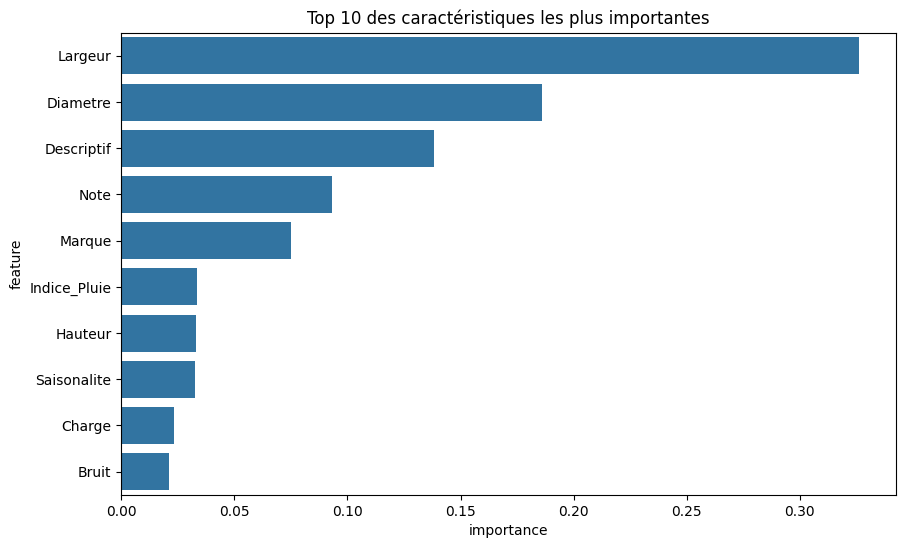

In [49]:
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nImportance des caractéristiques")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10), ax=ax)
ax.set_title("Top 10 des caractéristiques les plus importantes")
plt.show()